In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Loading the dataset from DB

In [8]:
from sqlalchemy import create_engine
import pandas as pd


def get_engine():
    engine = create_engine(
        "mssql+pyodbc://@ALLEN-TIDER/CREDT_SCORE?"
        "driver=ODBC+Driver+17+for+SQL+Server"
        "&trusted_connection=yes"
    )
    return engine


def fetch_data(query):
    try:
        engine = get_engine()
        df = pd.read_sql(query, engine)
        return df

    except Exception as e:
        print(f"Error: {e}")


query = "SELECT * FROM dbo.creditcard_data"

df = fetch_data(query)

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [12]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Dtypes:\n{df.dtypes}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Date range: {df['Time'].min()} to {df['Time'].max()}")
print(f"Target distribution:\n{df['Class'].value_counts(normalize=True)}")

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13 

In [13]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
def drop_columns(df, columns):
    """
    Drop specified columns from dataframe.

    Args:
        df (pd.DataFrame): Input dataframe
        columns (list): Columns to drop

    Returns:
        pd.DataFrame
    """

    try:
        existing_cols = [col for col in columns if col in df.columns]

        if existing_cols:
            df = df.drop(columns=existing_cols)
            print(f"Dropped columns: {existing_cols}")
        else:
            print("No matching columns found.")

        return df

    except Exception as e:
        print(f"Error: {e}")

In [20]:
df = drop_columns(df, ["Time"])

Dropped columns: ['Time']


In [21]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Univarite Analysis

In [22]:
from scipy.stats import skew


def analyze_numerical_columns(df):
    """
    Analyze numerical columns for:
    - Distribution shape
    - Outliers (1.5 * IQR)
    - Min/Max range

    Args:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Numerical feature analysis report
    """

    try:
        numerical_cols = df.select_dtypes(
            include=["int64", "float64"]
        ).columns

        analysis_results = []

        for col in numerical_cols:

            # Basic stats
            min_val = df[col].min()
            max_val = df[col].max()
            mean_val = df[col].mean()
            median_val = df[col].median()

            # Skewness
            skewness = skew(df[col].dropna())

            # Distribution shape
            if abs(skewness) < 0.5:
                distribution = "Approximately Normal"
            elif abs(skewness) < 1:
                distribution = "Moderately Skewed"
            else:
                distribution = "Highly Skewed"

            # Bimodal check (simple heuristic)
            q1, q2, q3 = (
                df[col].quantile(0.25),
                df[col].quantile(0.50),
                df[col].quantile(0.75)
            )

            if (q3 - q2) > 2 * (q2 - q1):
                distribution += " / Possibly Bimodal"

            # IQR Outlier Detection
            IQR = q3 - q1

            lower_bound = q1 - (1.5 * IQR)
            upper_bound = q3 + (1.5 * IQR)

            outlier_count = df[
                (df[col] < lower_bound)
                | (df[col] > upper_bound)
            ].shape[0]

            outlier_percentage = round(
                (outlier_count / len(df)) * 100, 2
            )

            # Range sanity
            range_status = (
                "Looks Reasonable"
                if np.isfinite(min_val)
                and np.isfinite(max_val)
                else "Check Range"
            )

            analysis_results.append({
                "Column": col,
                "Distribution": distribution,
                "Skewness": round(skewness, 2),
                "Min": min_val,
                "Max": max_val,
                "Mean": round(mean_val, 2),
                "Median": round(median_val, 2),
                "Outlier Count": outlier_count,
                "Outlier %": outlier_percentage,
                "Range Status": range_status
            })

        result_df = pd.DataFrame(analysis_results)

        print("Numerical column analysis completed.")

        return result_df

    except Exception as e:
        print(f"Error during numerical analysis: {e}")

In [23]:
numerical_report = analyze_numerical_columns(df)

numerical_report

Numerical column analysis completed.


,Column,Distribution,Skewness,Min,Max,Mean,Median,Outlier Count,Outlier %,Range Status
0,V1,Highly Skewed,-3.28,-56.407510,2.454930,0.00,0.02,7062,2.48,Looks Reasonable
1,V2,Highly Skewed,-4.62,-72.715728,22.057729,0.00,0.07,13526,4.75,Looks Reasonable
2,V3,Highly Skewed,-2.24,-48.325589,9.382558,-0.00,0.18,3363,1.18,Looks Reasonable
3,V4,Moderately Skewed,0.68,-5.683171,16.875344,0.00,-0.02,11148,3.91,Looks Reasonable
4,V5,Highly Skewed,-2.43,-113.743307,34.801666,0.00,-0.05,12295,4.32,Looks Reasonable
5,V6,Highly Skewed,1.83,-26.160506,73.301626,0.00,-0.27,22965,8.06,Looks Reasonable
6,V7,Highly Skewed,2.55,-43.557242,120.589494,-0.00,0.04,8948,3.14,Looks Reasonable
7,V8,Highly Skewed,-8.52,-73.216718,20.007208,0.00,0.02,24134,8.47,Looks Reasonable
8,V9,Moderately Skewed,0.55,-13.434066,15.594995,-0.00,-0.05,8283,2.91,Looks Reasonable
9,V10,Highly Skewed,1.19,-24.588262,23.745136,0.00,-0.09,9496,3.33,Looks Reasonable


In [25]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')

In [26]:
def plot_numerical_analysis(df, columns, n_cols=3):
    """
    Plot distribution and boxplot
    for numerical columns.

    Args:
        df (pd.DataFrame): Input dataframe
        columns (list): Numerical columns
        n_cols (int): Number of columns in grid
    """

    try:
        for col in columns:

            fig, axes = plt.subplots(
                1, 2,
                figsize=(14, 4)
            )

            # Distribution plot
            sns.histplot(
                df[col],
                kde=True,
                ax=axes[0]
            )

            axes[0].set_title(
                f"{col} Distribution"
            )
            axes[0].set_xlabel(col)

            # Boxplot
            sns.boxplot(
                x=df[col],
                ax=axes[1]
            )

            axes[1].set_title(
                f"{col} Outliers"
            )

            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error: {e}")

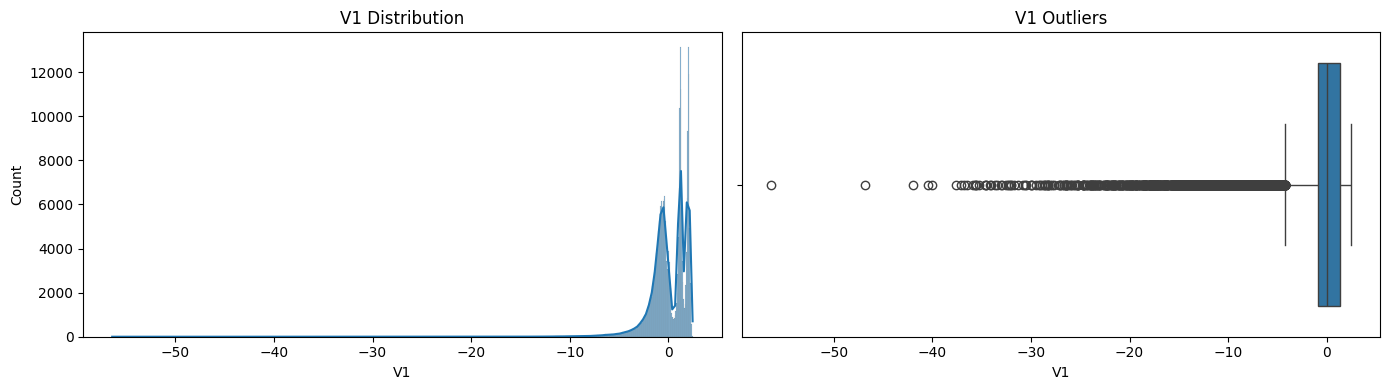

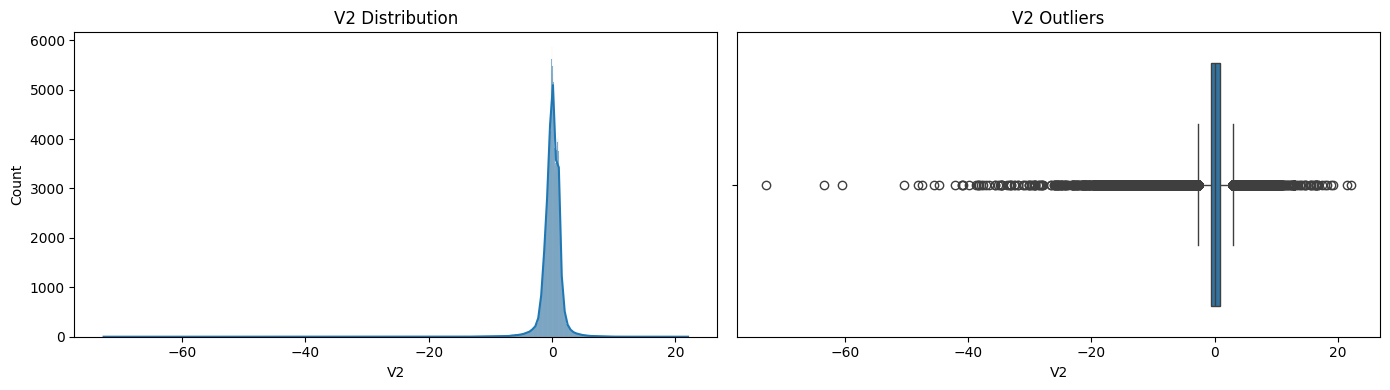

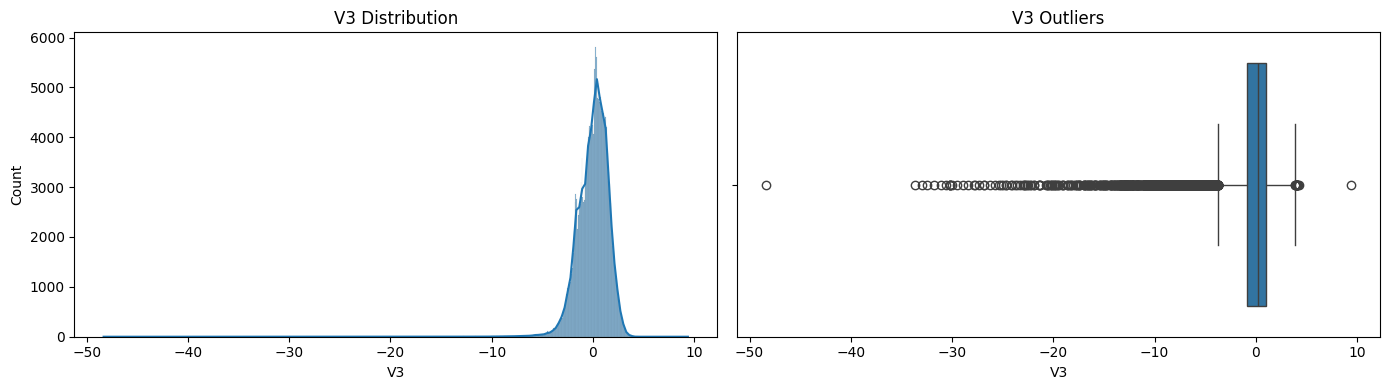

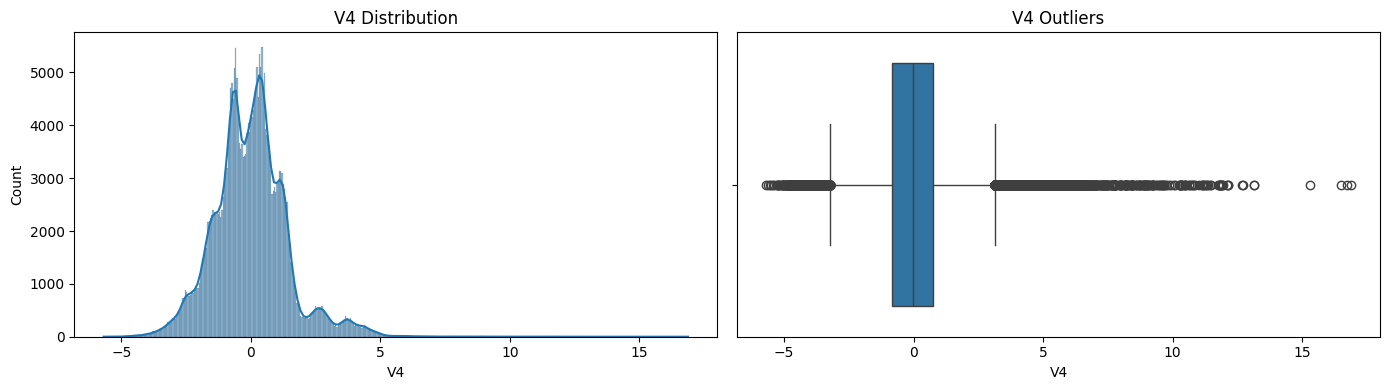

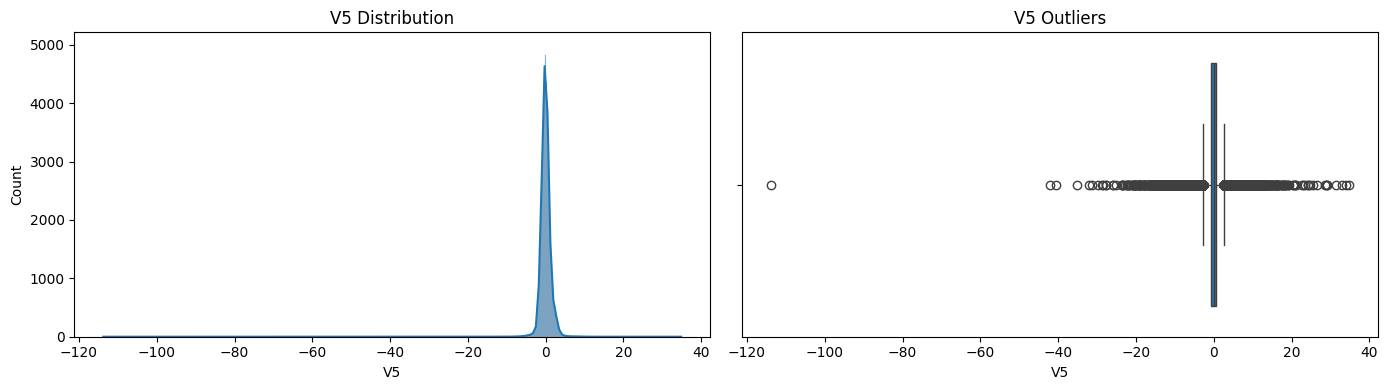

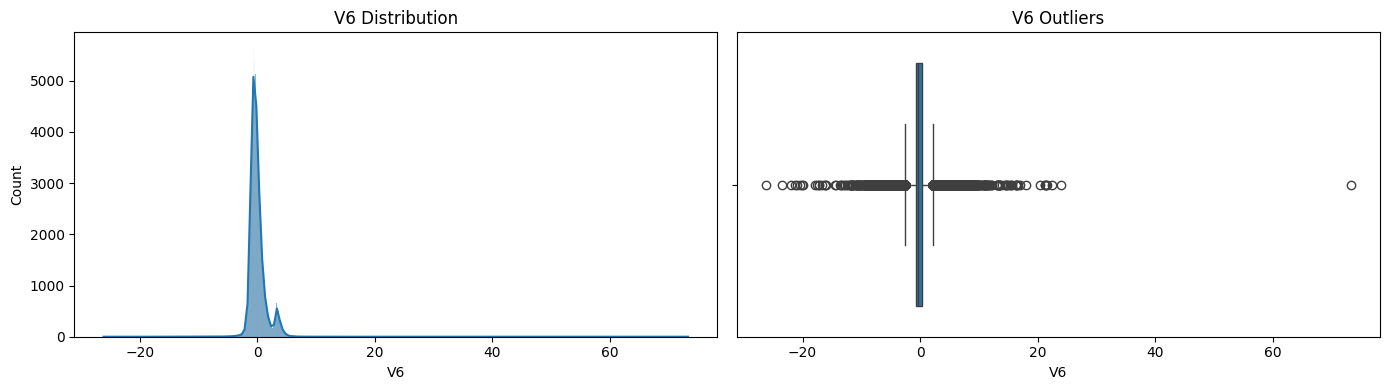

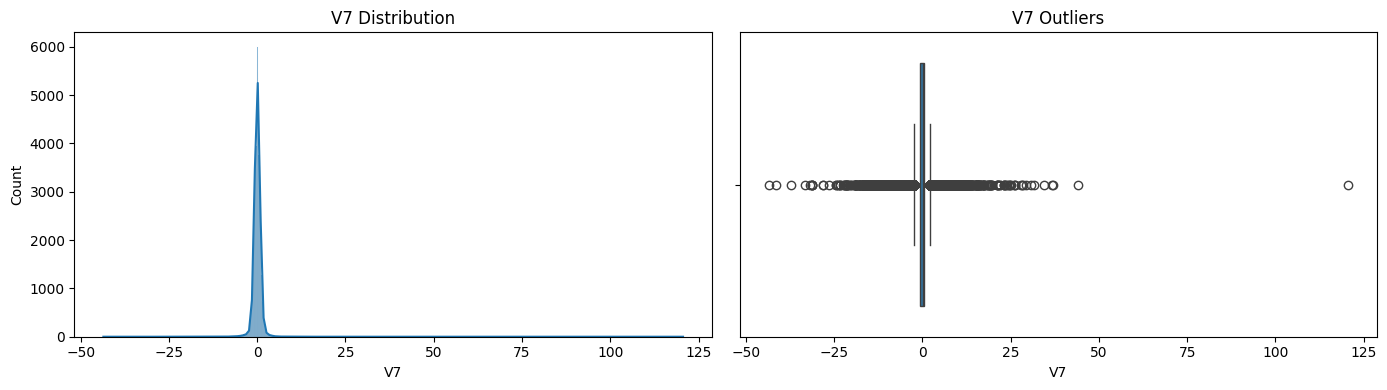

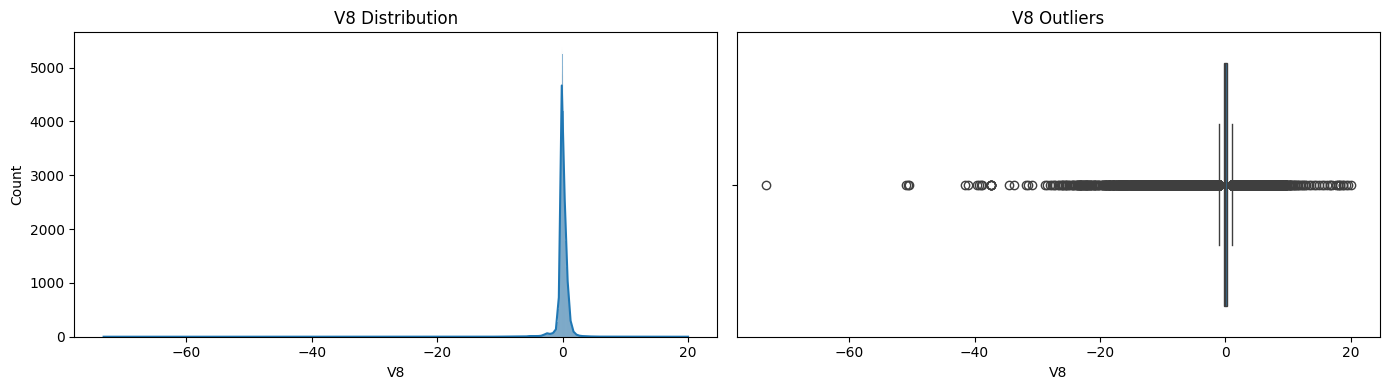

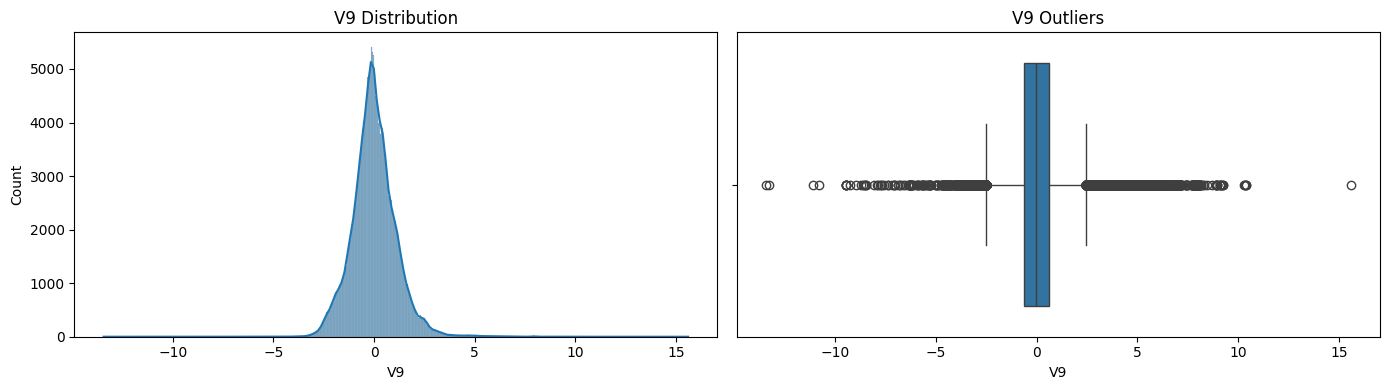

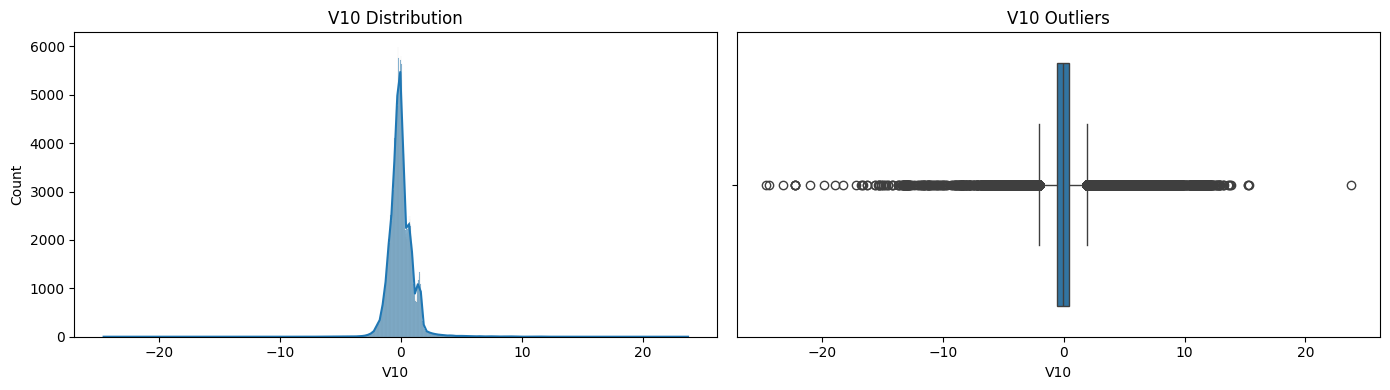

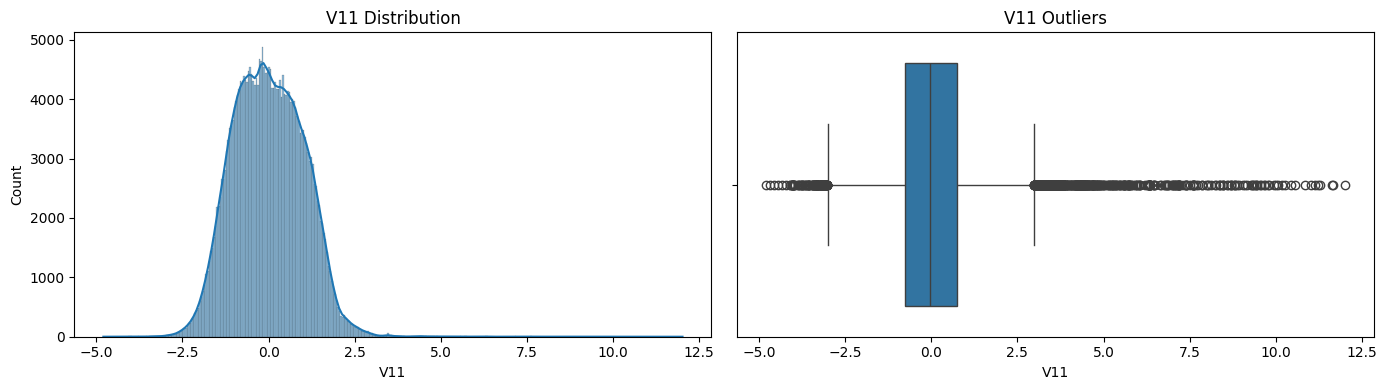

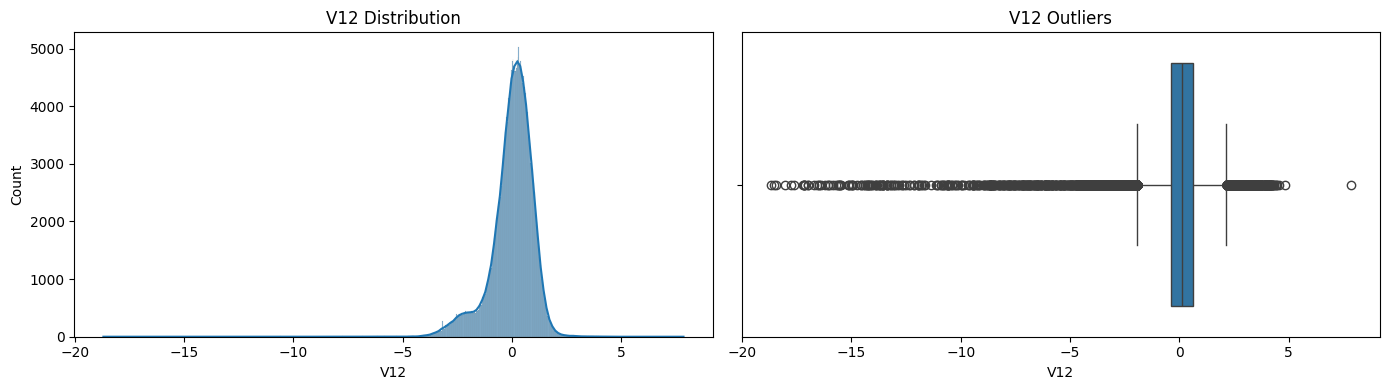

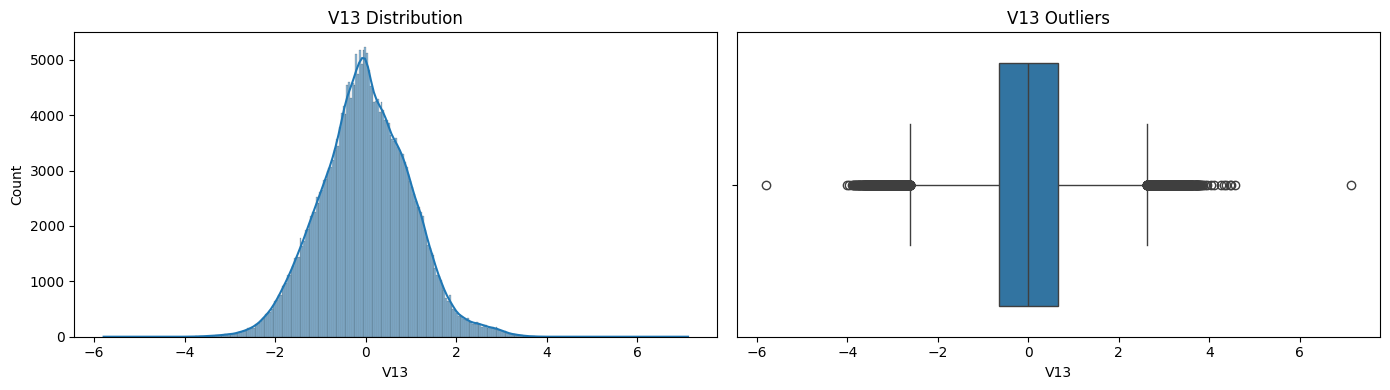

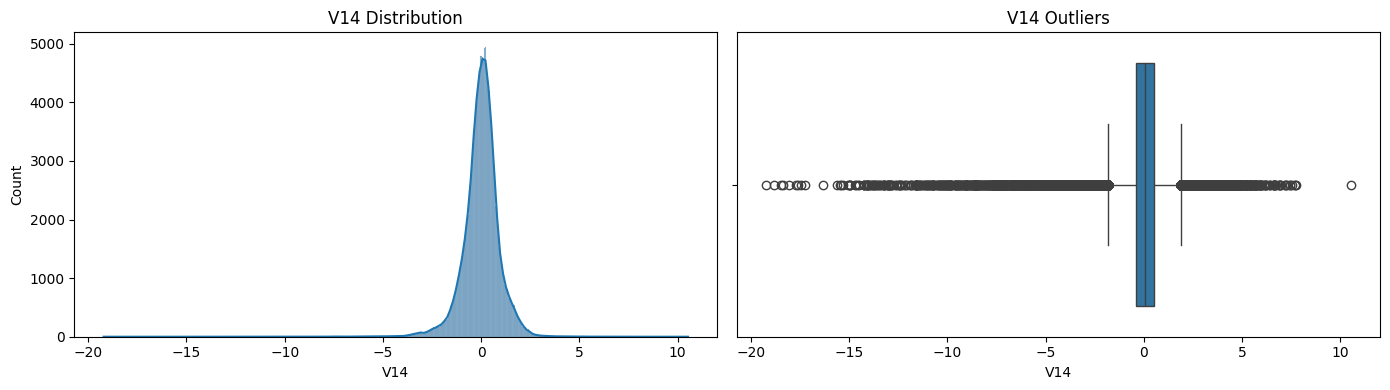

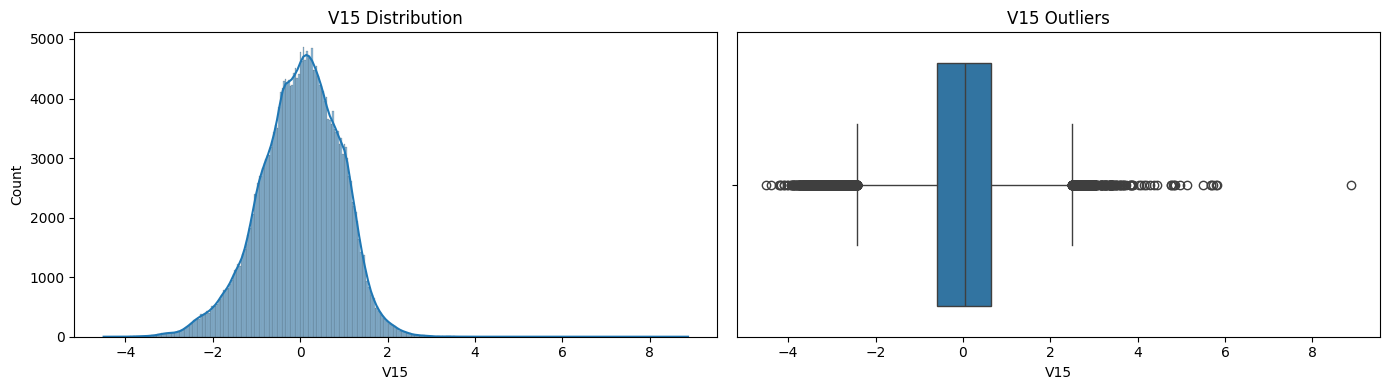

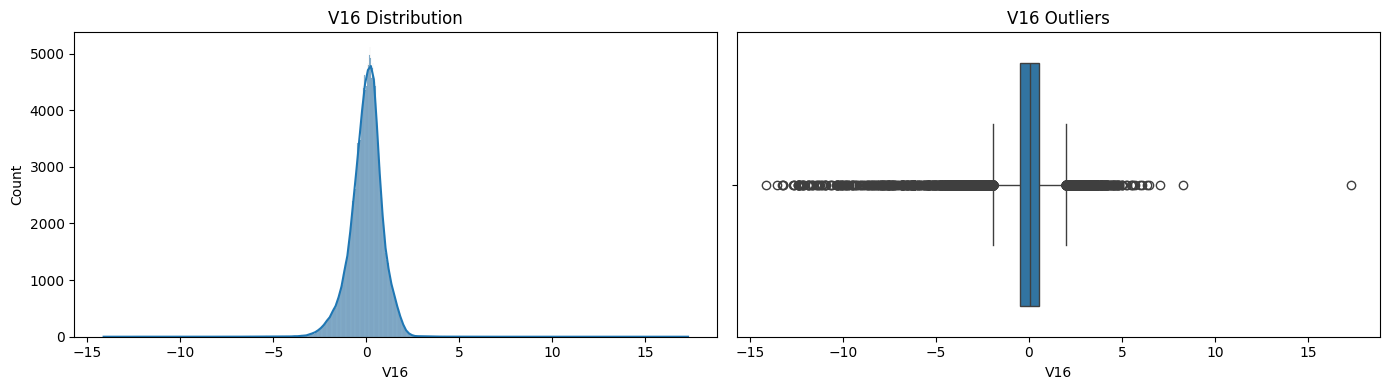

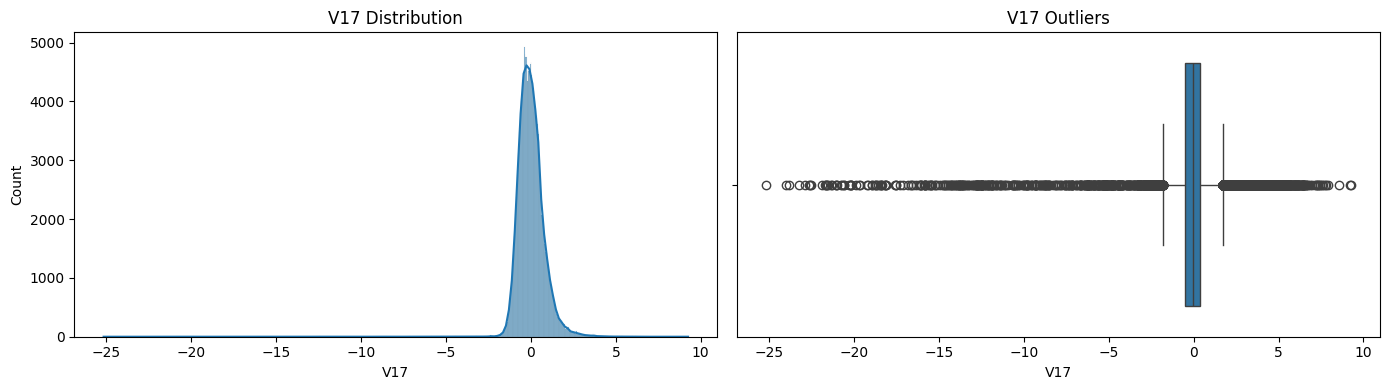

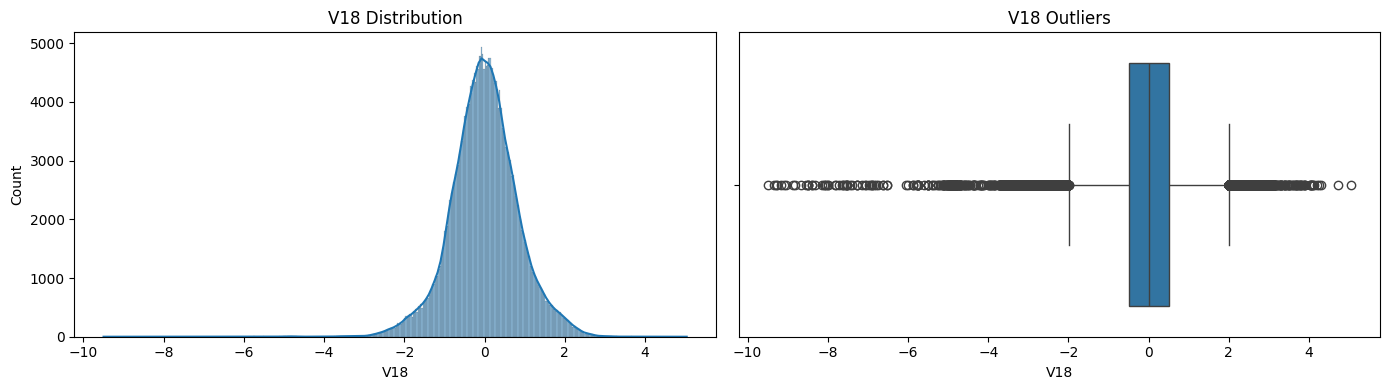

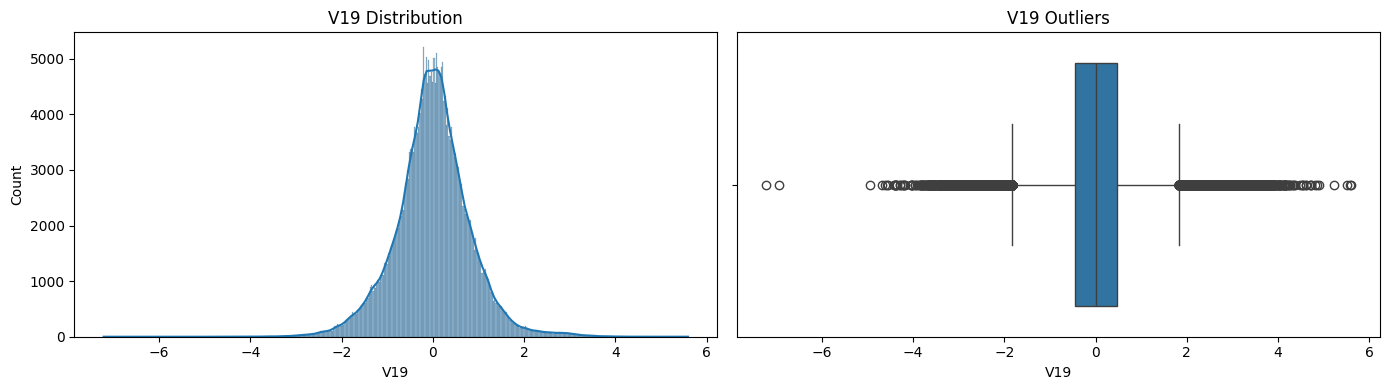

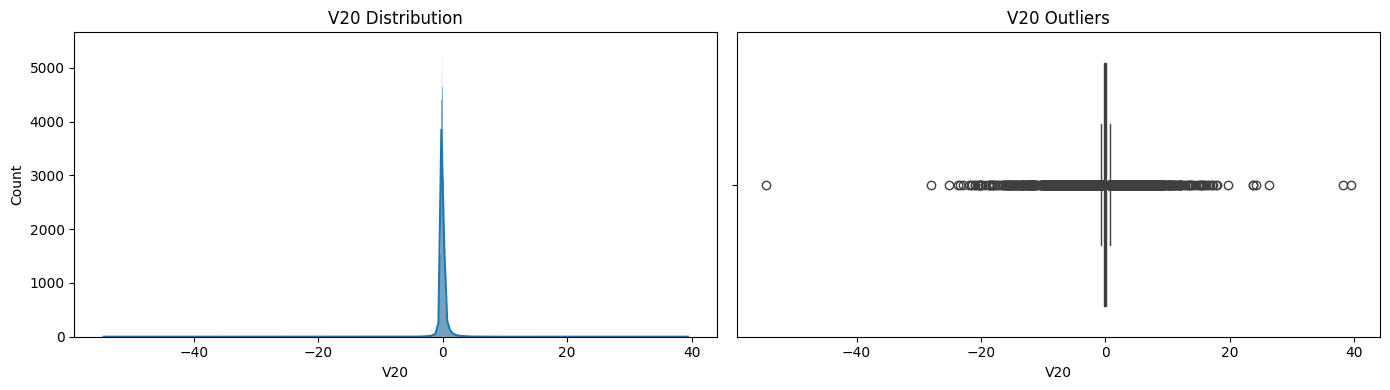

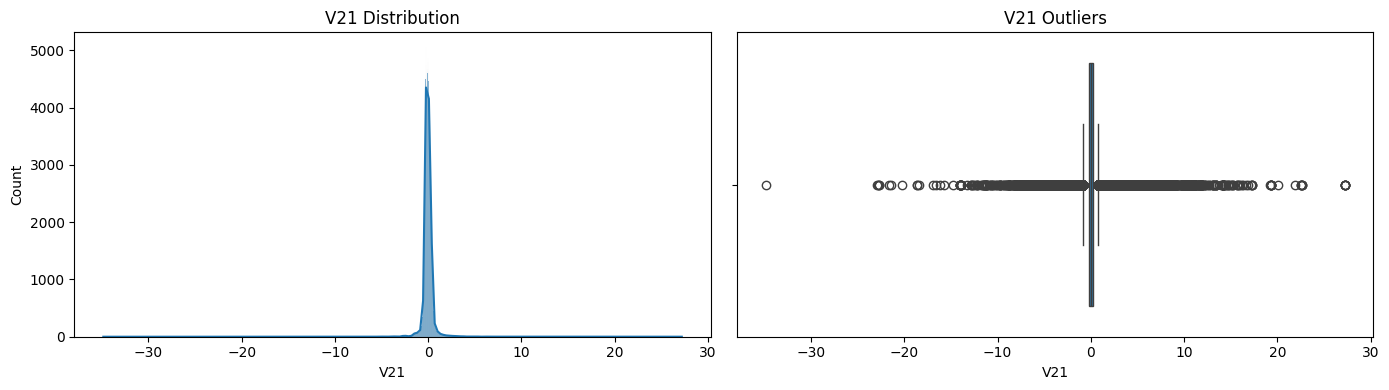

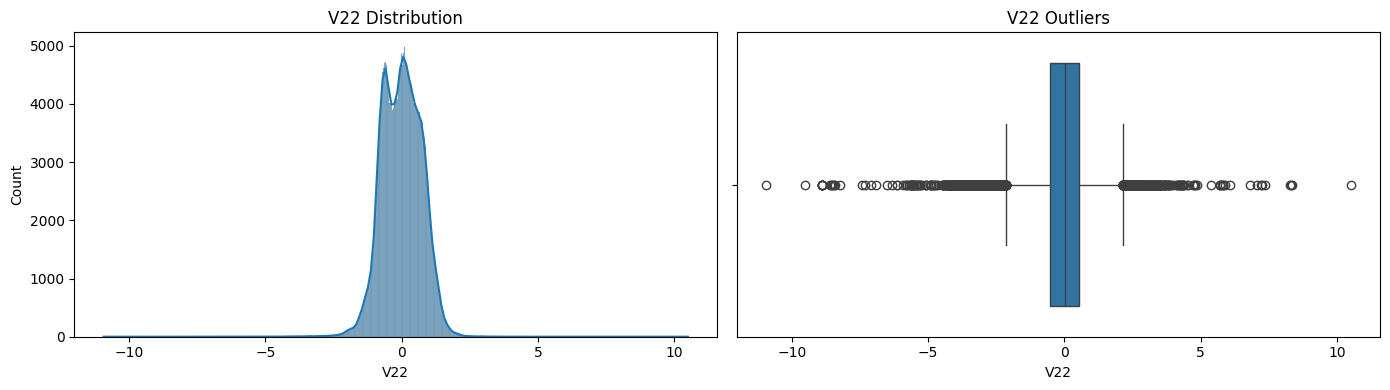

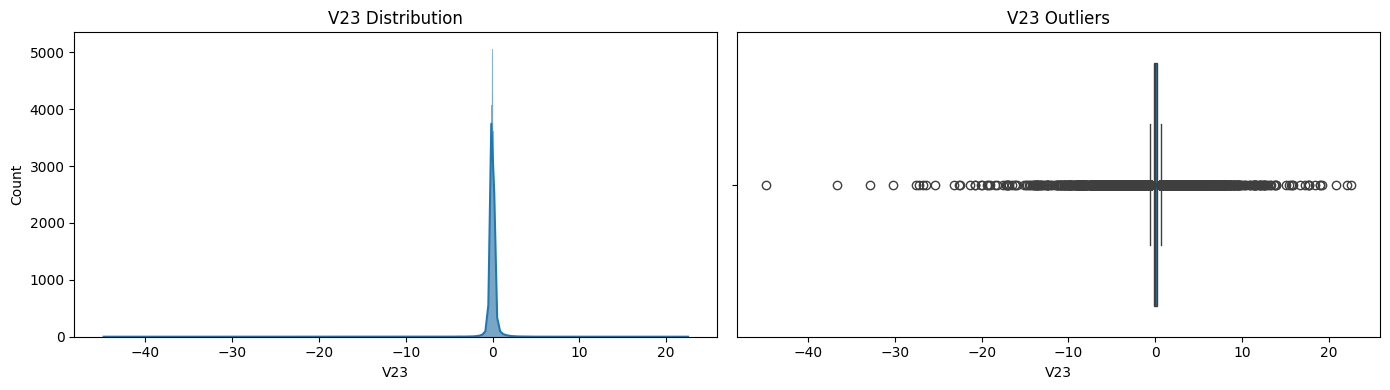

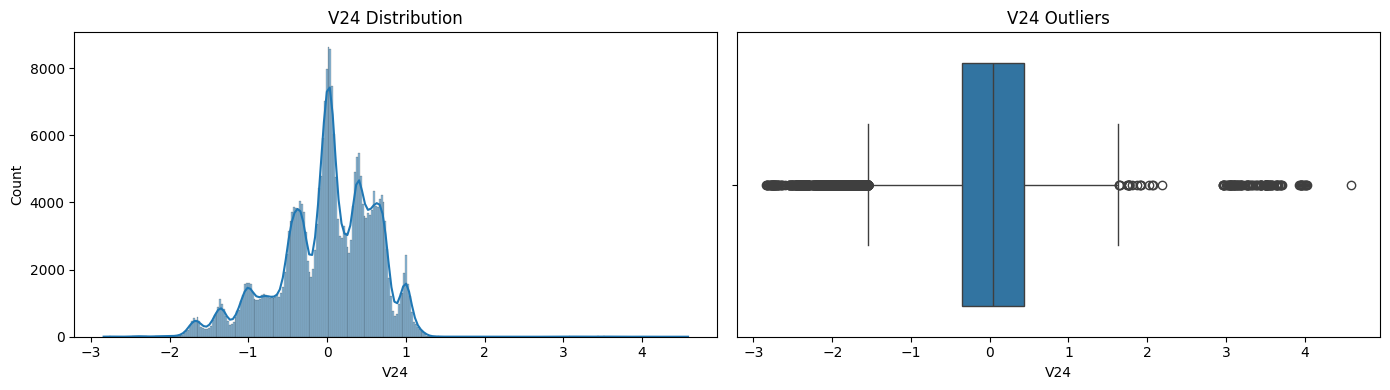

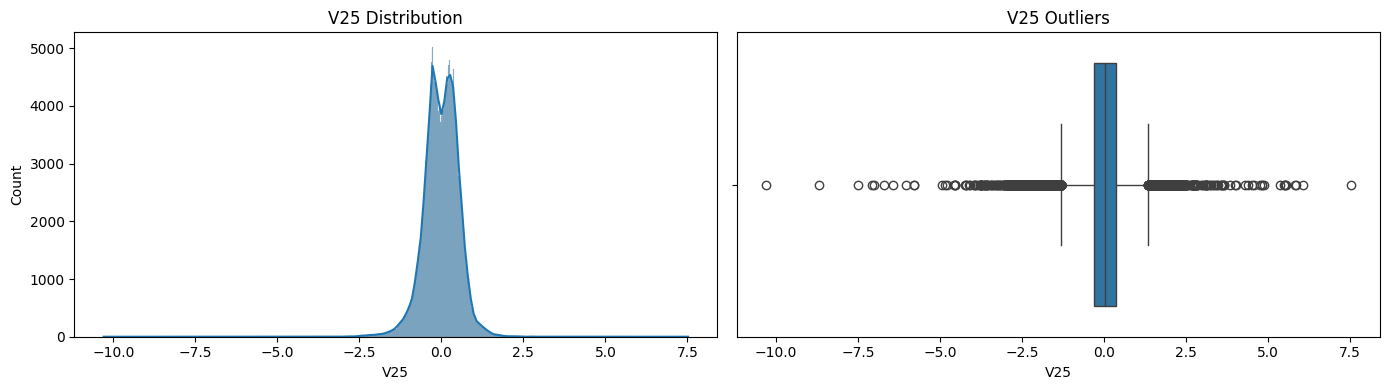

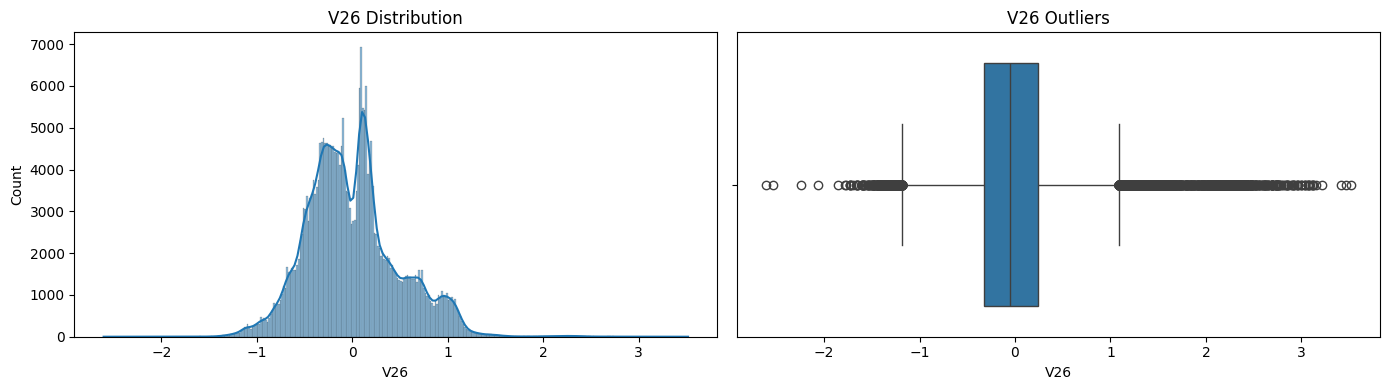

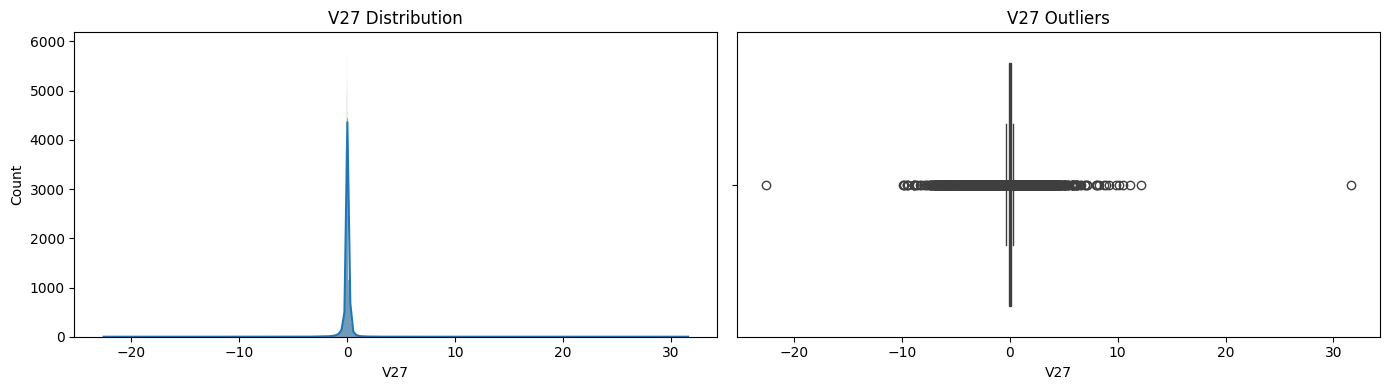

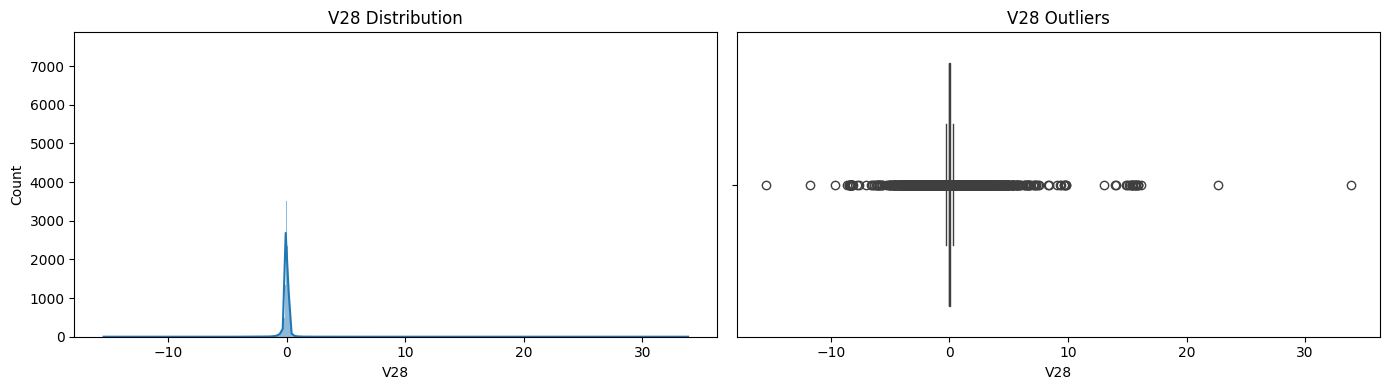

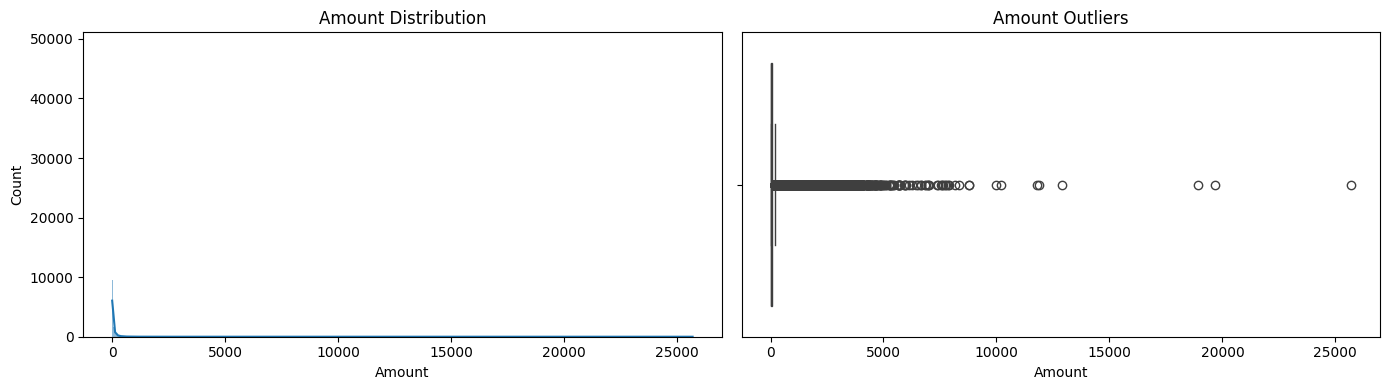

In [27]:
columns = [
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8',
    'V9', 'V10', 'V11', 'V12', 'V13', 'V14',
    'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
    'V21', 'V22', 'V23', 'V24', 'V25', 'V26',
    'V27', 'V28', 'Amount'
]

plot_numerical_analysis(df, columns)

In [28]:
def correlation_analysis(
    df,
    target_col="Class",
    corr_threshold=0.8
):
    """
    Perform correlation analysis.

    - Correlation heatmap
    - Highly correlated features
    - Correlation with target
    - Potential leakage detection

    Args:
        df (pd.DataFrame)
        target_col (str)
        corr_threshold (float)

    Returns:
        dict
    """

    try:
        # Correlation matrix
        corr_matrix = df.corr()

        # Heatmap
        plt.figure(figsize=(18, 12))

        sns.heatmap(
            corr_matrix,
            cmap="coolwarm",
            center=0
        )

        plt.title(
            "Correlation Matrix"
        )

        plt.show()

        # --------------------------
        # Highly correlated features
        # --------------------------
        high_corr_pairs = []

        for i in range(len(corr_matrix.columns)):
            for j in range(i):

                corr_value = corr_matrix.iloc[i, j]

                if abs(corr_value) > corr_threshold:

                    high_corr_pairs.append({
                        "Feature_1":
                        corr_matrix.columns[i],

                        "Feature_2":
                        corr_matrix.columns[j],

                        "Correlation":
                        round(corr_value, 2)
                    })

        high_corr_df = pd.DataFrame(
            high_corr_pairs
        )

        # --------------------------
        # Correlation with target
        # --------------------------
        target_corr = (
            corr_matrix[target_col]
            .sort_values(
                ascending=False
            )
        )

        print(
            "\nTop Features Correlated "
            f"with {target_col}:"
        )

        print(target_corr)

        # --------------------------
        # Potential leakage
        # --------------------------
        leakage_features = target_corr[
            abs(target_corr) > 0.95
        ]

        if len(leakage_features) > 1:
            print(
                "\n⚠ Potential Data Leakage:"
            )
            print(leakage_features)

        return {
            "correlation_matrix":
            corr_matrix,

            "highly_correlated_features":
            high_corr_df,

            "target_correlations":
            target_corr
        }

    except Exception as e:
        print(f"Error: {e}")

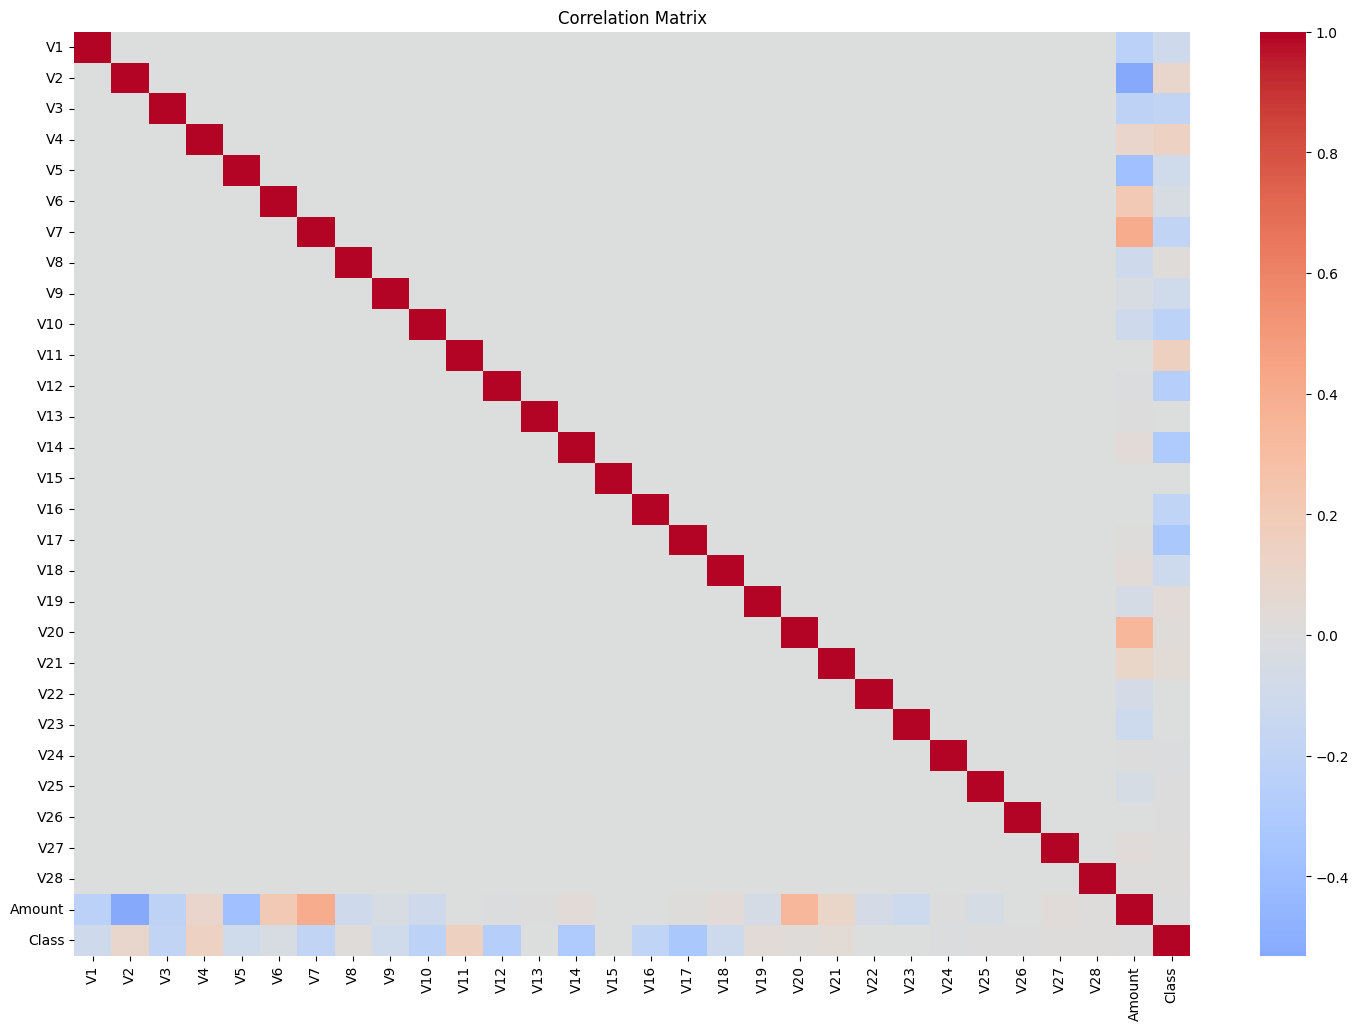


Top Features Correlated with Class:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [29]:
results = correlation_analysis(
    df,
    target_col="Class",
    corr_threshold=0.8
)

In [30]:
results[
    "highly_correlated_features"
]

""


In [31]:
results[
    "target_correlations"
]

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

#### Remove Duplicates

In [32]:
def drop_duplicates(df):
    """
    Remove duplicate rows from dataframe.

    Args:
        df (pd.DataFrame): Input dataframe

    Returns:
        pd.DataFrame: Dataframe without duplicates
    """

    try:
        # Count duplicates
        duplicate_count = df.duplicated().sum()

        print(
            f"Number of duplicate rows: "
            f"{duplicate_count}"
        )

        # Shape before
        before_shape = df.shape

        # Drop duplicates
        df = df.drop_duplicates()

        # Shape after
        after_shape = df.shape

        print(
            f"Shape before removing duplicates: "
            f"{before_shape}"
        )

        print(
            f"Shape after removing duplicates: "
            f"{after_shape}"
        )

        print(
            "Duplicates removed successfully."
        )

        return df

    except Exception as e:
        print(
            f"Error removing duplicates: {e}"
        )

In [33]:
df = drop_duplicates(df)

Number of duplicate rows: 9144
Shape before removing duplicates: (284807, 30)
Shape after removing duplicates: (275663, 30)
Duplicates removed successfully.


#### Datatype Correction

In [35]:
def convert_column_types(
    df,
    categorical_cols=None,
    numeric_cols=None
):
    """
    Convert dataframe column types.

    Args:
        df (pd.DataFrame):
            Input dataframe

        categorical_cols (list):
            Columns to convert
            into category dtype

        numeric_cols (list):
            Columns to convert
            into numeric dtype

    Returns:
        pd.DataFrame
    """

    try:
        # Convert categorical columns
        if categorical_cols:
            for col in categorical_cols:

                if col in df.columns:
                    df[col] = (
                        df[col]
                        .astype("category")
                    )

                    print(
                        f"{col} converted "
                        "to category"
                    )

                else:
                    print(
                        f"{col} not found"
                    )

        # Convert numeric columns
        if numeric_cols:
            for col in numeric_cols:

                if col in df.columns:
                    df[col] = (
                        pd.to_numeric(
                            df[col],
                            errors="coerce"
                        )
                    )

                    print(
                        f"{col} converted "
                        "to numeric"
                    )

                else:
                    print(
                        f"{col} not found"
                    )

        print(
            "\nDatatype conversion "
            "completed."
        )

        return df

    except Exception as e:
        print(
            f"Error converting "
            f"datatypes: {e}"
        )

In [36]:
df = convert_column_types(
    df,
    categorical_cols=["Class"],
    numeric_cols=["Amount"]
)

Class converted to category
Amount converted to numeric

Datatype conversion completed.


In [38]:
from sklearn.preprocessing import RobustScaler


def scale_amount_column(df, column_name="Amount"):
    """
    Scale Amount column using RobustScaler.

    Args:
        df (pd.DataFrame):
            Input dataframe

        column_name (str):
            Column to scale

    Returns:
        tuple:
            - transformed dataframe
            - fitted scaler
    """

    try:
        # Check if column exists
        if column_name not in df.columns:
            raise ValueError(
                f"{column_name} column not found."
            )

        # Initialize scaler
        scaler = RobustScaler()

        # Scale column
        df[column_name] = scaler.fit_transform(
            df[[column_name]]
        )

        print(
            f"{column_name} scaled "
            "successfully using RobustScaler."
        )

        return df, scaler

    except Exception as e:
        print(
            f"Error scaling "
            f"{column_name}: {e}"
        )

In [39]:
df, amount_scaler = scale_amount_column(df)

Amount scaled successfully using RobustScaler.


In [44]:
import os
import joblib


def save_scaler(scaler, path):
    """
    Save scaler object.

    Args:
        scaler: fitted scaler
        path (str): save path
    """

    try:
        # Create folder if missing
        os.makedirs(
            os.path.dirname(path),
            exist_ok=True
        )

        # Save scaler
        joblib.dump(
            scaler,
            path
        )

        print(
            f"Scaler saved at: {path}"
        )

    except Exception as e:
        print(
            f"Error saving scaler: {e}"
        )

In [45]:
save_scaler(
    amount_scaler,
    "artifacts/amount_scaler.pkl"
)

Scaler saved at: artifacts/amount_scaler.pkl


Splitting the data

In [47]:
from sklearn.model_selection import train_test_split


def split_data(
    df,
    target_column="Class",
    test_size=0.2,
    random_state=42
):
    """
    Split dataset into train and test.

    Args:
        df (pd.DataFrame)
        target_column (str)
        test_size (float)
        random_state (int)

    Returns:
        tuple
    """

    try:
        # Features & target
        X = df.drop(
            columns=[target_column]
        )

        y = df[target_column]

        # Split
        X_train, X_test, y_train, y_test = (
            train_test_split(
                X,
                y,
                test_size=test_size,
                random_state=random_state,
                stratify=y
            )
        )

        print(
            "Train-test split successful."
        )

        print(
            f"X_train: {X_train.shape}"
        )

        print(
            f"X_test: {X_test.shape}"
        )

        return (
            X_train,
            X_test,
            y_train,
            y_test
        )

    except Exception as e:
        print(f"Error: {e}")

In [48]:
X_train, X_test, y_train, y_test = split_data(df)

Train-test split successful.
X_train: (220530, 29)
X_test: (55133, 29)


In [49]:
def calculate_scale_pos_weight(
    y_train
):
    """
    Calculate imbalance ratio
    for XGBoost.
    """

    negative_class = (
        y_train.value_counts()[0]
    )

    positive_class = (
        y_train.value_counts()[1]
    )

    scale_pos_weight = (
        negative_class
        /
        positive_class
    )

    print(
        f"scale_pos_weight: "
        f"{scale_pos_weight:.2f}"
    )

    return scale_pos_weight

In [50]:
scale_pos_weight = (
    calculate_scale_pos_weight(
        y_train
    )
)

scale_pos_weight: 582.41


In [51]:
from xgboost import (
    XGBClassifier
)


def train_xgboost_model(
    X_train,
    y_train,
    scale_pos_weight
):

    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,

        scale_pos_weight=
        scale_pos_weight,

        eval_metric="logloss",

        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    print(
        "XGBoost model "
        "trained successfully."
    )

    return model

In [52]:
model = train_xgboost_model(
    X_train,
    y_train,
    scale_pos_weight
)

XGBoost model trained successfully.


In [53]:
def get_prediction_probabilities(
    model,
    X_test
):

    y_probs = (
        model.predict_proba(
            X_test
        )[:, 1]
    )

    return y_probs

In [54]:
y_probs = (
    get_prediction_probabilities(
        model,
        X_test
    )
)

In [55]:
from sklearn.metrics import (
    precision_recall_curve
)
import matplotlib.pyplot as plt


def plot_precision_recall_curve(
    y_test,
    y_probs
):

    precision, recall, thresholds = (
        precision_recall_curve(
            y_test,
            y_probs
        )
    )

    plt.figure(
        figsize=(8, 6)
    )

    plt.plot(
        thresholds,
        precision[:-1],
        label="Precision"
    )

    plt.plot(
        thresholds,
        recall[:-1],
        label="Recall"
    )

    plt.xlabel(
        "Threshold"
    )

    plt.ylabel(
        "Score"
    )

    plt.title(
        "Precision-Recall "
        "vs Threshold"
    )

    plt.legend()

    plt.show()

    return (
        precision,
        recall,
        thresholds
    )

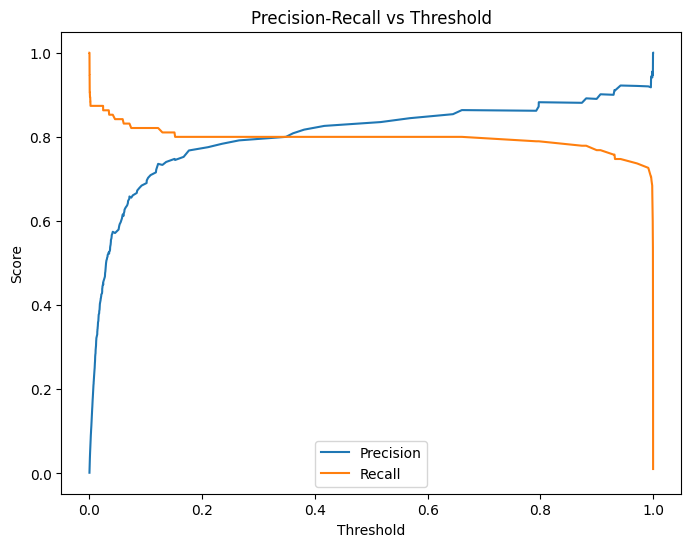

In [56]:
precision, recall, thresholds = (
    plot_precision_recall_curve(
        y_test,
        y_probs
    )
)

In [57]:
import numpy as np


def apply_threshold(
    y_probs,
    threshold=0.2
):

    y_pred = np.where(
        y_probs >= threshold,
        1,
        0
    )

    return y_pred

In [61]:
y_pred = apply_threshold(
    y_probs,
    threshold=0.15
)

In [62]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)


def evaluate_model(
    y_test,
    y_pred,
    y_probs
):

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    print(
        "\nConfusion Matrix:"
    )

    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )

    print(
        "\nROC-AUC:"
    )

    print(
        roc_auc_score(
            y_test,
            y_probs
        )
    )

In [63]:
evaluate_model(
    y_test,
    y_pred,
    y_probs
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.75      0.81      0.78        95

    accuracy                           1.00     55133
   macro avg       0.87      0.91      0.89     55133
weighted avg       1.00      1.00      1.00     55133


Confusion Matrix:
[[55012    26]
 [   18    77]]

ROC-AUC:
0.9823622339398042


In [64]:
for threshold in [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
]:

    y_pred = apply_threshold(
        y_probs,
        threshold
    )

    print(
        f"\nThreshold: "
        f"{threshold}"
    )

    evaluate_model(
        y_test,
        y_pred,
        y_probs
    )


Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.69      0.82      0.75        95

    accuracy                           1.00     55133
   macro avg       0.84      0.91      0.87     55133
weighted avg       1.00      1.00      1.00     55133


Confusion Matrix:
[[55003    35]
 [   17    78]]

ROC-AUC:
0.9823622339398042

Threshold: 0.15
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.75      0.81      0.78        95

    accuracy                           1.00     55133
   macro avg       0.87      0.91      0.89     55133
weighted avg       1.00      1.00      1.00     55133


Confusion Matrix:
[[55012    26]
 [   18    77]]

ROC-AUC:
0.9823622339398042

Threshold: 0.2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.78      0